# K-Nearest Neighbors (KNN) Classification Model

Objective: Develop a K-Nearest Neighbors (KNN) Classification Model to explore how instance-based learning can classify new data points according to their similarity with existing observations. 

In [5]:
from pathlib import Path
import pandas as pd

# Importar dataset
DATA_PATH = Path.cwd() / "seattle-weather-dataset.csv"

data = pd.read_csv(DATA_PATH)
df = pd.DataFrame(data)
df = df.drop(columns=['date']) # Ignorar esta columna, pues no será necesaria para el análisis

print("Sample data:")
df.head(4)

Sample data:


,precipitation,temp_max,temp_min,wind,weather
0,0.0,12.8,5.0,4.7,drizzle
1,10.9,10.6,2.8,4.5,rain
2,0.8,11.7,7.2,2.3,rain
3,20.3,12.2,5.6,4.7,rain


## 1. Identificar el equilibrio de clases del conjunto de datos

Es necesario identificar si el conjunto de datos está equilibrado o desequilibrado calculando la proporción de muestras en cada clase. 

En el caso de este dataset, se puede observar un **desequlibrio evidente**, pues la clase de "sun" y "rain" tienen un porcentaje alto respectivamente (de 43.81% y 43.87% respectivamente), mientras que el resto de las clases ("drizzle", "snow" y "fog") representan solo el 12.32% del resto del dataset, véase la información obtenida con el código para más detalles.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Selección de solo las columnas numéricas del DataFrame para usar como variables predictoras
num_cols = df.select_dtypes(include='number').columns

# Definir la matriz de X (features) y la variable objetivo y
# X contiene todas las columnas numéricas, excepto la clase a predecir
# y contiene la columna "weather", que será la etiqueta del modelo
X = df[num_cols].copy()
y = df["weather"].copy()

"""
Obtener información relevante
"""

# Muestra la forma del dataset original y de los conjuntos creados
print("---- Forma del dataset original ----")
print("df:", df.shape)
print("X:", X.shape)

# Muestra las columnas que se usarán como entrada del modelo
print("\nColumnas:")
print(X.columns.tolist())

# Muestra el tipo de dato de cada columna para verificar el tipo de datos que manejan
print("\nTipos:")
print(X.dtypes)

# Muestra la distribución original de las clases para detectar si el dataset está balanceado
class_counts = Counter(y)
total = len(y)

print("\nOriginal class distribution (count):", class_counts)
print("\nOriginal class distribution (%):")
for label, count in class_counts.items():
    pct = (count / total) * 100
    print(f"{label}: {count} ({pct:.2f}%)")


---- Forma del dataset original ----
df: (1461, 5)
X: (1461, 4)

Columnas:
['precipitation', 'temp_max', 'temp_min', 'wind']

Tipos:
precipitation    float64
temp_max         float64
temp_min         float64
wind             float64
dtype: object

Original class distribution (count): Counter({'rain': 641, 'sun': 640, 'fog': 101, 'drizzle': 53, 'snow': 26})

Original class distribution (%):
drizzle: 53 (3.63%)
rain: 641 (43.87%)
sun: 640 (43.81%)
snow: 26 (1.78%)
fog: 101 (6.91%)


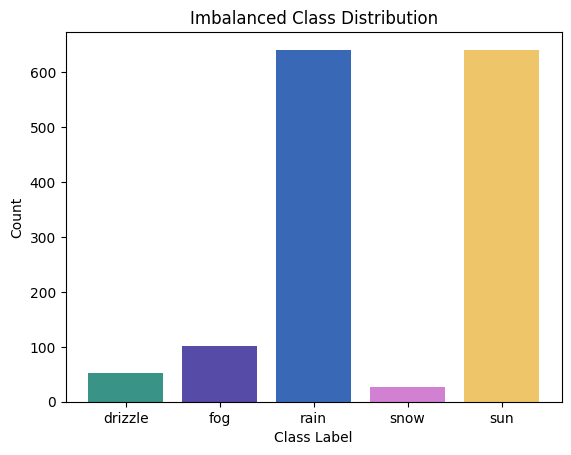

In [7]:
# Graficar la distribución de clases
classes, counts = np.unique(y, return_counts=True)

colors_classes = ["#399387", "#564BA6", "#3969B6", "#D281D2", "#EEC669"]

plt.figure()
plt.bar(classes, counts, color=colors_classes)

plt.xlabel("Class Label")
plt.ylabel("Count")
plt.title("Imbalanced Class Distribution")
plt.xticks(classes)
plt.show()

## 2. Mitigación del desequilibrio

Con el fin de mitigar los problemas de ajuste insuficiente o sobreajuste debido al desbalance del dataset, se deben de aplicar técnicas apropiadas para abordarlo, ya sea a través de un sobremuestreo o un muestreo insuficiente. 

En este caso, el enfoque es de: oversampling. Con ello se busca igual la cantidad de muestras de cada clase con la de

In [8]:
from sklearn.utils import resample
import pandas as pd
import plotly.express as px

# Buscar la clase con más datos en la columna 'weather' y guardar el valor máximo 
max_count = df['weather'].value_counts().max()

# Separar el DataFrame por clase y sobremuestrear cada grupo
# hasta alcanzar el número de muestras de la clase mayoritaria.
balanced_parts = [
    resample(
        group,
        replace=True,
        n_samples=max_count,
        random_state=42
    )
    for _, group in df.groupby("weather")
]

# Unir todas las clases balanceadas, mezclar las filas
# y restablecer el índice del nuevo DataFrame.
balanced_df = (
    pd.concat(balanced_parts)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

# Definir nuevos objetivos con base en los cambios realizados
X = balanced_df[num_cols].copy()
y = balanced_df["weather"].copy()

# ----------------------------- #
# Obtener información relevante #
# ----------------------------- #

# Muestra la forma del dataset oversampled y de los conjuntos creados
print("---- Forma del dataset oversampled y datos de entrenamiento y prueba ----")
print("Balanced df:", balanced_df.shape)

# Muestra las columnas que se usarán como entrada del modelo
print("\nColumnas:")
print(X.columns.tolist())

# Muestra el tipo de dato de cada columna para verificar el tipo de datos que manejan
print("\nTipos:")
print(X.dtypes)

# Muestra la distribución original de las clases para detectar si el dataset está balanceado
class_counts = Counter(y)
total = len(y)

print("\nBalanced class distribution (count):", class_counts)
print("\nBalanced class distribution (%):")
for label, count in class_counts.items():
    pct = (count / total) * 100
    print(f"{label}: {count} ({pct:.2f}%)")


---- Forma del dataset oversampled y datos de entrenamiento y prueba ----
Balanced df: (3205, 5)

Columnas:
['precipitation', 'temp_max', 'temp_min', 'wind']

Tipos:
precipitation    float64
temp_max         float64
temp_min         float64
wind             float64
dtype: object

Balanced class distribution (count): Counter({'drizzle': 641, 'sun': 641, 'snow': 641, 'rain': 641, 'fog': 641})

Balanced class distribution (%):
drizzle: 641 (20.00%)
sun: 641 (20.00%)
snow: 641 (20.00%)
rain: 641 (20.00%)
fog: 641 (20.00%)


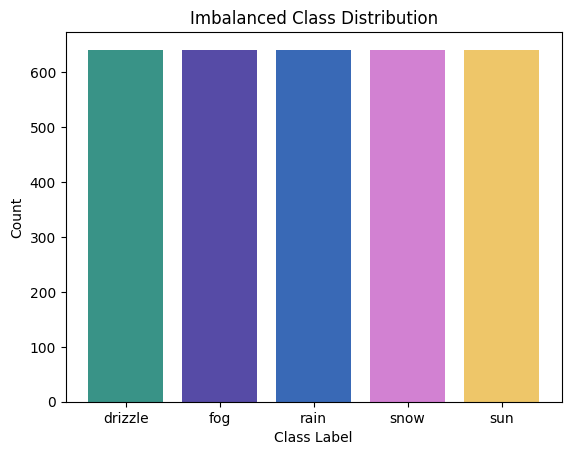

In [9]:
# Graficar la distribución de clases balanceadas
classes, counts = np.unique(y, return_counts=True)

plt.figure()
plt.bar(classes, counts, color=colors_classes)

plt.xlabel("Class Label")
plt.ylabel("Count")
plt.title("Imbalanced Class Distribution")
plt.xticks(classes)
plt.show()

## 3. Preparar datos para el modelado

In [11]:
from sklearn.model_selection import train_test_split

# Definir features y target
num_cols = balanced_df.select_dtypes(include='number').columns
X = balanced_df[num_cols].copy()
y = balanced_df['weather'].copy()

print("Features:", X.columns.tolist())
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Dividir set de entrenamiento y de testeo (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Features: ['precipitation', 'temp_max', 'temp_min', 'wind']
Features shape: (3205, 4)
Target shape: (3205,)

Training set size: 2243
Testing set size: 962


In [13]:
from sklearn.preprocessing import StandardScaler

# Estandarización de features para KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Estadísticas del escalamiento de features:")
print(X_train_scaled_df.describe().round(2))
print("* Para una mejor interpretación, considerar los siguientes valores:  mean ≈ 0, std ≈ 1")

Estadísticas del escalamiento de features:
       precipitation  temp_max  temp_min     wind
count        2243.00   2243.00   2243.00  2243.00
mean           -0.00      0.00     -0.00     0.00
std             1.00      1.00      1.00     1.00
min            -0.48     -1.86     -2.32    -1.79
25%            -0.48     -0.85     -0.89    -0.80
50%            -0.48     -0.16     -0.03    -0.21
75%             0.06      0.85      0.84     0.72
max             8.47      2.54      2.10     4.15
* Para una mejor interpretación, considerar los siguientes valores:  mean ≈ 0, std ≈ 1


## 4. Construcción de un KNN Classifier con valores de hiperparámetros determinados

Para esta sección, se construye un clasificador KNN con valores de hiperparámetros que permitan la correcta configuración del modelo. Concretamente, su elección está basada en función de la comprensión teórica y la experimentación previa en lugar de a través de la optimización automatizada.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

"""
Búsqueda de la mejor combinación de parámetros
"""
# Setting de hiperparámetros posibles para el árbol
knn = KNeighborsClassifier(
    n_neighbors=3,        # Número de vecinos (clásico, balance bias-varianza)
    weights='distance',   # Ponderación por distancia (vecinos más cercanos pesan más)
    metric='minkowski',   # Métrica de distancia flexible
    p=2                   # p=2 corresponde a distancia Euclidiana
)

print("Entrenando modelo KNN...")
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

print("Entrenamiento terminado")

Entrenando modelo KNN...
Entrenamiento terminado



Hyperparameters seleccionados:
  n_neighbors: 5
  weights: distance
  metric: minkowski
  p: 2

Reporte de clasificación:
              precision    recall  f1-score   support

     drizzle       0.92      1.00      0.96       193
         fog       0.87      0.99      0.93       192
        rain       0.96      0.89      0.92       192
        snow       0.98      1.00      0.99       193
         sun       0.95      0.78      0.86       192

    accuracy                           0.93       962
   macro avg       0.94      0.93      0.93       962
weighted avg       0.94      0.93      0.93       962


Accuracy: 0.9335


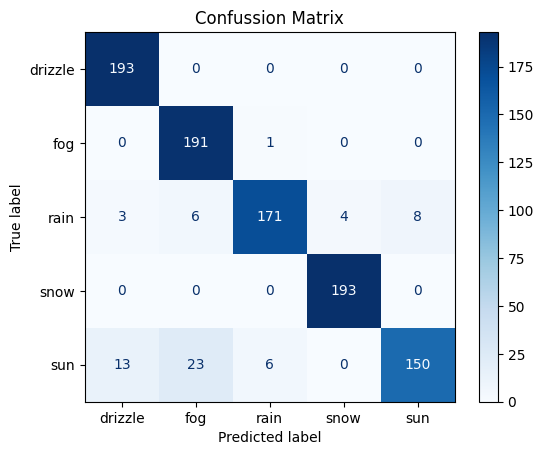

In [34]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

print("\nHyperparameters seleccionados:")
print(f"  n_neighbors: {knn.n_neighbors}")
print(f"  weights: {knn.weights}")
print(f"  metric: {knn.metric}")
print(f"  p: {knn.p}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=knn.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confussion Matrix")
plt.show()

# Análisis final del Modelo KNN

## Elección de hiperparámetros y su efecto en el rendimiento del modelo

Los hiperparámetros del modelo KNN fueron seleccionados manualmente basados en comprensión teórica: **n_neighbors=5**, **weights='distance'**, **metric='minkowski'** y **p=2** (distancia Euclidiana). Esta configuración logró una precisión global del **93.35%**, con un rendimiento destacado en la clase "snow" (F1-score de 0.99) y un desempeño más modesto en "sun" (F1-score de 0.86). El uso de **weights='distance'** fue crucial, ya que otorga mayor influencia a los vecinos más cercanos, lo que mejora la precisión al reducir el impacto de vecinos lejanos que podrían introducir ruido en la clasificación. El valor de **k=5** representa un equilibrio óptimo entre sesgo y varianza: un valor menor (k=1) habría provocado sobreajuste al depender de un solo vecino, mientras que un valor mayor (k=15) habría generado subajuste al suavizar excesivamente las fronteras de decisión.

## Análisis general



### Análisis de fronteras de decisión y capacidad Predictiva


### Impacto de la Configuración de Parámetros en la Generalización

